In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate, MultiHeadAttention

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [5]:
kwh_data = data[['temp', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,cloudcover,solarradiation,conditions
datetime,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,41.7,0.0,Partially cloudy
...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_6001/4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7


In [7]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1,0.0000
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1,0.0000
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1,0.0000
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1,0.0000
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7,0.0000


In [8]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh,Kwh
datetime,,,,,,,,,
2022-01-01 00:00:00,6.0,0.0,0.0,0,0,1,1,0.0000,0.0000
2022-01-01 01:00:00,6.0,0.0,0.0,0,1,1,1,0.0000,0.0000
2022-01-01 02:00:00,4.9,40.9,0.0,2,2,1,1,0.0000,0.0000
2022-01-01 03:00:00,4.0,38.0,0.0,2,3,1,1,0.0000,0.0000
2022-01-01 04:00:00,3.0,41.7,0.0,2,4,1,1,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,79.3,207.0,2,19,4,7,0.0592,0.0592
2024-07-04 20:00:00,23.0,81.7,103.0,5,20,4,7,0.0085,0.0085
2024-07-04 21:00:00,21.0,63.7,9.0,5,21,4,7,0.0000,0.0000


In [9]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :8])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7
0,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
1,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
3,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
4,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
5,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890
6,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890
7,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890
8,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965
9,-0.844550,0.058244,-0.580657,0.662831,-0.361218,-1.662386,-1.452052,-0.234996


In [10]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7
datetime,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121
2024-07-04 20:00:00,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731
2024-07-04 21:00:00,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890


In [11]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh.columns = ["temp", "cloudcover", "solarradiation", "conditions_int", "hour", "day", "month", "Kwh Train", "Kwh Target"]
df_scaled_kwh.head(20)


,temp,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh Train,Kwh Target
datetime,,,,,,,,,
2022-01-01 00:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965,0.0305


In [12]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=5)
reshaped_df


,temp1,cloudcover1,solarradiation1,conditions_int1,hour1,day1,month1,Kwh Train1,temp2,cloudcover2,...,Kwh Train4,temp5,cloudcover5,solarradiation5,conditions_int5,hour5,day5,month5,Kwh Train5,Kwh Target
0,-0.844550,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,-0.844550,-1.229211,...,-0.679890,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
1,-0.844550,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,-0.969842,-0.176073,...,-0.679890,-1.186254,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890,0.0000
2,-0.969842,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,-1.072353,-0.250745,...,-0.679890,-1.072353,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890,0.0000
3,-1.072353,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,-1.186254,-0.155474,...,-0.679890,-0.844550,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890,0.0305
4,-1.186254,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,-1.186254,-0.209547,...,-0.679890,-0.958452,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965,0.0991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21973,1.433478,-0.585484,0.228662,0.662831,0.361106,-1.322047,0.316003,1.903281,1.547379,1.005811,...,0.070729,1.205675,0.871915,1.121182,3.349560,0.938965,-1.322047,0.316003,0.351762,0.0592
21974,1.547379,1.005811,3.333572,0.662831,0.505571,-1.322047,0.316003,0.325724,1.319577,1.142281,...,0.351762,1.205675,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121,0.0085
21975,1.319577,1.142281,2.429706,-0.232745,0.650035,-1.322047,0.316003,0.207205,1.091774,1.083058,...,-0.414121,1.091774,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731,0.0000
21976,1.091774,1.083058,0.448010,0.662831,0.794500,-1.322047,0.316003,0.070729,1.205675,0.871915,...,-0.641731,0.863971,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890,0.0000


In [13]:
reshaped_df.iloc[0]

temp1             -0.844550
cloudcover1       -1.229211
solarradiation1   -0.667640
conditions_int1   -1.128321
hour1             -1.661400
day1              -1.662386
month1            -1.452052
Kwh Train1        -0.679890
temp2             -0.844550
cloudcover2       -1.229211
solarradiation2   -0.667640
conditions_int2   -1.128321
hour2             -1.516935
day2              -1.662386
month2            -1.452052
Kwh Train2        -0.679890
temp3             -0.969842
cloudcover3       -0.176073
solarradiation3   -0.667640
conditions_int3    0.662831
hour3             -1.372470
day3              -1.662386
month3            -1.452052
Kwh Train3        -0.679890
temp4             -1.072353
cloudcover4       -0.250745
solarradiation4   -0.667640
conditions_int4    0.662831
hour4             -1.228006
day4              -1.662386
month4            -1.452052
Kwh Train4        -0.679890
temp5             -1.186254
cloudcover5       -0.155474
solarradiation5   -0.667640
conditions_int5    0

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [15]:
x_train.shape[1]

40

In [16]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((19780, 40), (19780,), (1099, 40), (1099,), (1099, 40), (1099,))

In [17]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [18]:
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),  
    layers.Dense(32, activation='relu'),  
    layers.Dense(1, activation= "relu")
])

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=20,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

Epoch 1/20
1120/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.0146
Epoch 1: val_loss improved from inf to 0.00611, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 1s 420us/step - loss: 0.0140 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/20
1090/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - loss: 0.0036
Epoch 2: val_loss improved from 0.00611 to 0.00567, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 302us/step - loss: 0.0036 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/20
1075/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - loss: 0.0032
Epoch 3: val_loss improved from 0.00567 to 0.00503, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - loss: 0.0032 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/20
1219/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - loss: 0.00

In [19]:
y_pred = model.predict(x_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 630us/step


In [20]:
y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.head(20)

,Predicted,True
0,0.0000,0.0000
1,0.0000,0.0016
2,0.0532,0.0463
3,0.2026,0.1792
4,0.3397,0.4355
5,0.5391,0.5716
6,0.6332,0.5960
7,0.6056,0.6821
8,0.6333,0.7122
9,0.5978,0.6767


In [21]:
date_range = pd.date_range(start='2024-05-20 05:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

1099

In [22]:
results_df.shape

(1099, 2)

In [23]:
results_df.index = date_range

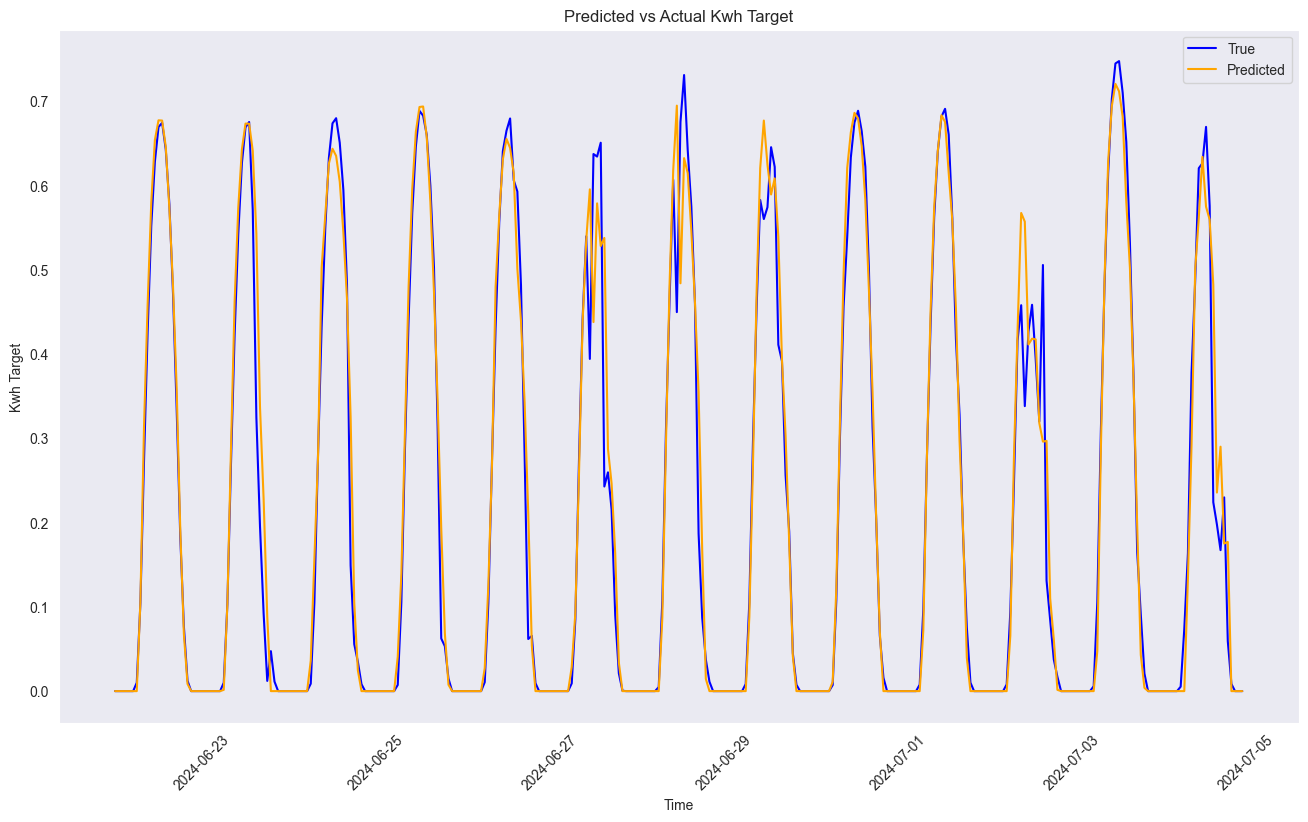

In [24]:
last_312_df = results_df.tail(312)


plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [25]:
r2_score(y_pred_flat, y_test_flat)

0.9502221004521647

<Axes: >

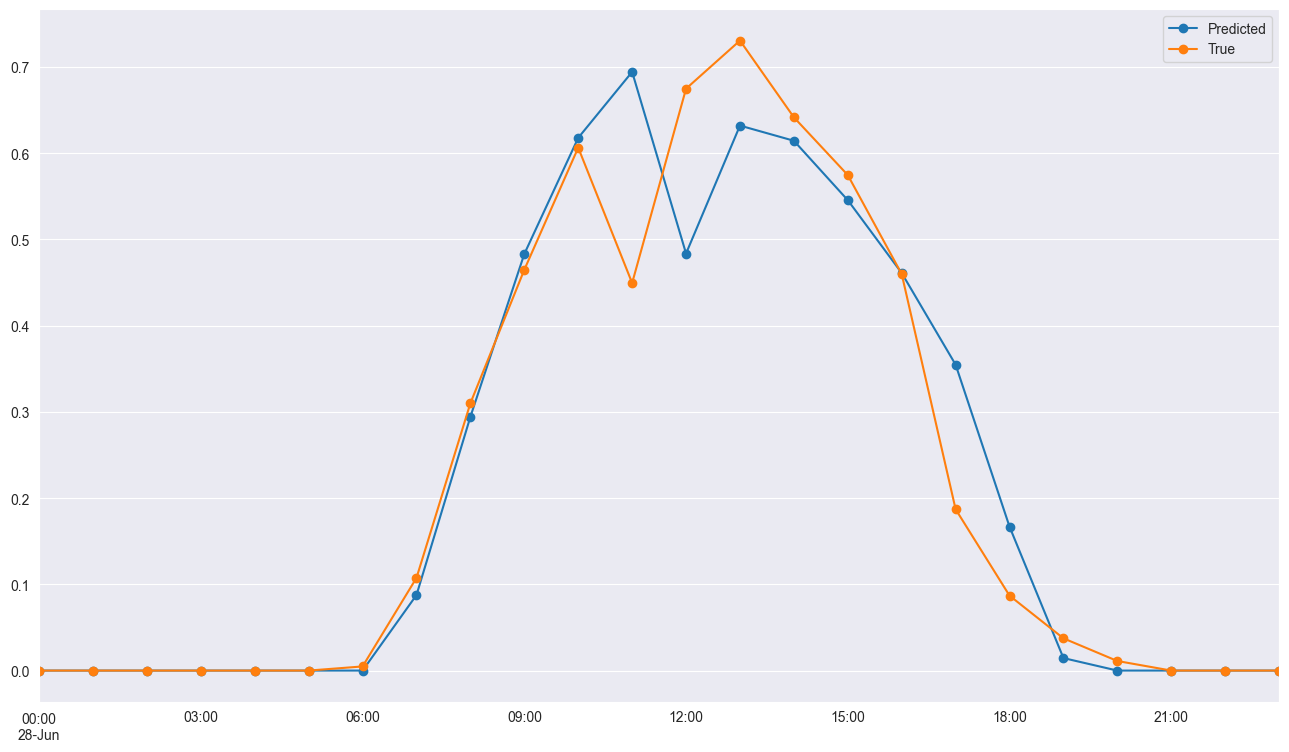

In [26]:
results_df[-168: - 144].plot(figsize=(16, 9), marker = 'o')

<Axes: >

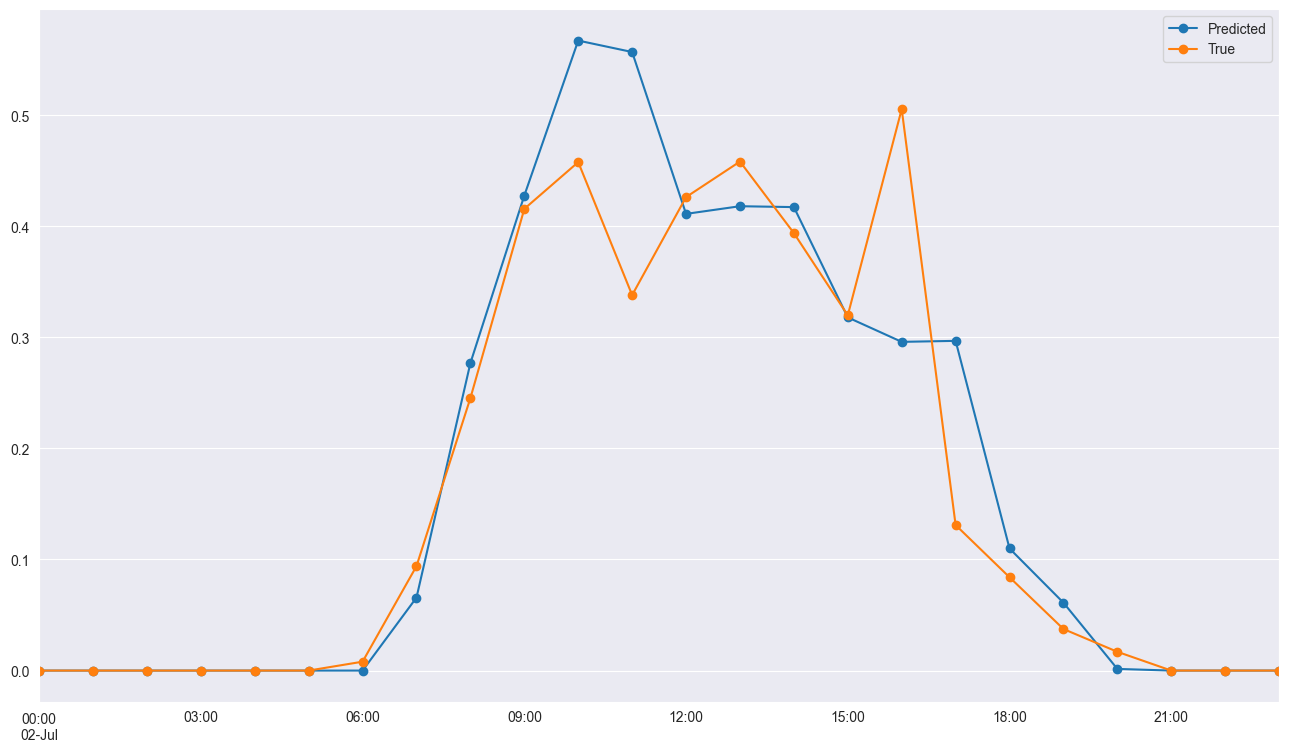

In [27]:
results_df[-72: -48].plot(figsize= (16, 9), marker = "o")

In [28]:
mean_squared_error(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.006006033416493396

In [29]:
r2_score(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.9115277007431868

# Weather Analysis of the predictions

In [30]:
results_df = results_df.tail(-19)
results_df

,Predicted,True
2024-05-21 00:00:00,0.0000,0.0000
2024-05-21 01:00:00,0.0000,0.0000
2024-05-21 02:00:00,0.0000,0.0000
2024-05-21 03:00:00,0.0000,0.0000
2024-05-21 04:00:00,0.0000,0.0000
...,...,...
2024-07-04 19:00:00,0.1769,0.0592
2024-07-04 20:00:00,0.0000,0.0085
2024-07-04 21:00:00,0.0000,0.0000
2024-07-04 22:00:00,0.0000,0.0000


In [31]:
common_index = kwh_data.index.intersection(results_df.index)
common_index

DatetimeIndex(['2024-05-21 00:00:00', '2024-05-21 01:00:00',
               '2024-05-21 02:00:00', '2024-05-21 03:00:00',
               '2024-05-21 04:00:00', '2024-05-21 05:00:00',
               '2024-05-21 06:00:00', '2024-05-21 07:00:00',
               '2024-05-21 08:00:00', '2024-05-21 09:00:00',
               ...
               '2024-07-04 14:00:00', '2024-07-04 15:00:00',
               '2024-07-04 16:00:00', '2024-07-04 17:00:00',
               '2024-07-04 18:00:00', '2024-07-04 19:00:00',
               '2024-07-04 20:00:00', '2024-07-04 21:00:00',
               '2024-07-04 22:00:00', '2024-07-04 23:00:00'],
              dtype='datetime64[ns]', length=1080, freq='H')

In [32]:
data_cleaned = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= 'datetime', parse_dates= True)
data_cleaned

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0000,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0000,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0000,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0000,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0000,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain


In [33]:
data_cleaned_same_index = data_cleaned.loc[common_index]
data_cleaned_same_index

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
2024-05-21 00:00:00,0.0000,"Kozani, Greece",17.0,17.0,15.0,88.00,0.0,0.0,0.0,13.5,5.4,160.0,1016.0,65.4,5.7,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 01:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,5.0,3.6,342.4,1016.0,94.1,1.9,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 02:00:00,0.0000,"Kozani, Greece",16.0,16.0,15.0,93.79,0.0,0.0,0.0,4.7,3.6,350.2,1016.0,100.0,15.4,0.0,0.0,0.0,Overcast,cloudy
2024-05-21 03:00:00,0.0000,"Kozani, Greece",15.0,15.0,14.0,93.72,0.0,0.0,0.0,15.3,5.4,237.0,1016.0,84.3,15.3,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2024-05-21 04:00:00,0.0000,"Kozani, Greece",14.0,14.0,14.0,100.00,0.0,0.0,0.0,6.8,5.4,350.2,1016.0,38.7,16.8,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,0.0592,"Kozani, Greece",24.0,24.0,10.0,41.15,0.0,0.0,0.0,22.0,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
2024-07-04 20:00:00,0.0085,"Kozani, Greece",23.0,23.0,9.0,40.87,0.1,0.0,0.0,22.0,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
2024-07-04 21:00:00,0.0000,"Kozani, Greece",21.0,21.0,10.0,49.39,0.1,0.0,0.0,14.4,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain
2024-07-04 22:00:00,0.0000,"Kozani, Greece",20.0,20.0,11.0,56.15,0.0,0.0,0.0,14.0,0.0,0.0,1012.0,65.5,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [34]:
eval_df = pd.concat([data_cleaned_same_index["conditions"], results_df], axis= 1)
eval_df

,conditions,Predicted,True
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 01:00:00,Overcast,0.0000,0.0000
2024-05-21 02:00:00,Overcast,0.0000,0.0000
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000
...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.1769,0.0592
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0000,0.0085
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0000,0.0000
2024-07-04 22:00:00,Partially cloudy,0.0000,0.0000


In [35]:
def categorize_condition(condition):
    if "Rain" in condition:
        return "Rain"
    elif "Clear" in condition:
        return "Clear"
    else:
        return "Cloudy"
    
    

eval_df["conditions_class"] = eval_df["conditions"].apply(categorize_condition)
eval_df

,conditions,Predicted,True,conditions_class
2024-05-21 00:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,Overcast,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,Partially cloudy,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,Partially cloudy,0.0000,0.0000,Cloudy
...,...,...,...,...
2024-07-04 19:00:00,Partially cloudy,0.1769,0.0592,Cloudy
2024-07-04 20:00:00,"Rain, Partially cloudy",0.0000,0.0085,Rain
2024-07-04 21:00:00,"Rain, Partially cloudy",0.0000,0.0000,Rain
2024-07-04 22:00:00,Partially cloudy,0.0000,0.0000,Cloudy


In [36]:
eval_df = eval_df.drop('conditions', axis=1)
eval_df

,Predicted,True,conditions_class
2024-05-21 00:00:00,0.0000,0.0000,Cloudy
2024-05-21 01:00:00,0.0000,0.0000,Cloudy
2024-05-21 02:00:00,0.0000,0.0000,Cloudy
2024-05-21 03:00:00,0.0000,0.0000,Cloudy
2024-05-21 04:00:00,0.0000,0.0000,Cloudy
...,...,...,...
2024-07-04 19:00:00,0.1769,0.0592,Cloudy
2024-07-04 20:00:00,0.0000,0.0085,Rain
2024-07-04 21:00:00,0.0000,0.0000,Rain
2024-07-04 22:00:00,0.0000,0.0000,Cloudy


In [37]:
eval_df['team'] = (eval_df.reset_index().index // 24) + 1  
eval_df

,Predicted,True,conditions_class,team
2024-05-21 00:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 01:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 02:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 03:00:00,0.0000,0.0000,Cloudy,1
2024-05-21 04:00:00,0.0000,0.0000,Cloudy,1
...,...,...,...,...
2024-07-04 19:00:00,0.1769,0.0592,Cloudy,45
2024-07-04 20:00:00,0.0000,0.0085,Rain,45
2024-07-04 21:00:00,0.0000,0.0000,Rain,45
2024-07-04 22:00:00,0.0000,0.0000,Cloudy,45


In [38]:
eval_df_non_zero = eval_df[eval_df['True'] != 0]
eval_df_non_zero

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0000,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0547,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2309,0.2481,Cloudy,1
2024-05-21 09:00:00,0.4031,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5152,0.5608,Cloudy,1
...,...,...,...,...
2024-07-04 16:00:00,0.2355,0.1976,Cloudy,45
2024-07-04 17:00:00,0.2899,0.1672,Cloudy,45
2024-07-04 18:00:00,0.1750,0.2298,Rain,45
2024-07-04 19:00:00,0.1769,0.0592,Cloudy,45


In [39]:
cloudy_eval_df_non_zero = eval_df_non_zero[eval_df_non_zero['conditions_class'] == "Cloudy"]
cloudy_eval_df_non_zero.head()

,Predicted,True,conditions_class,team
2024-05-21 06:00:00,0.0000,0.0043,Cloudy,1
2024-05-21 07:00:00,0.0547,0.0643,Cloudy,1
2024-05-21 08:00:00,0.2309,0.2481,Cloudy,1
2024-05-21 09:00:00,0.4031,0.4276,Cloudy,1
2024-05-21 10:00:00,0.5152,0.5608,Cloudy,1


In [40]:
cloudy_data_frame_grouped = cloudy_eval_df_non_zero['conditions_class'].groupby(cloudy_eval_df_non_zero.index.date).value_counts() > 5
cloudy_data_frame_grouped

            conditions_class
2024-05-21  Cloudy               True
2024-05-22  Cloudy               True
2024-05-23  Cloudy               True
2024-05-24  Cloudy               True
2024-05-25  Cloudy               True
2024-05-26  Cloudy               True
2024-05-27  Cloudy               True
2024-05-28  Cloudy               True
2024-05-29  Cloudy               True
2024-05-30  Cloudy               True
2024-05-31  Cloudy               True
2024-06-01  Cloudy               True
2024-06-02  Cloudy               True
2024-06-03  Cloudy               True
2024-06-04  Cloudy               True
2024-06-05  Cloudy               True
2024-06-06  Cloudy               True
2024-06-07  Cloudy               True
2024-06-08  Cloudy               True
2024-06-09  Cloudy               True
2024-06-10  Cloudy               True
2024-06-11  Cloudy               True
2024-06-12  Cloudy               True
2024-06-13  Cloudy               True
2024-06-14  Cloudy               True
2024-06-15  Cloudy   

In [41]:
daily_r2_scores = {}
grouped = eval_df.groupby(eval_df.index.date)  

for date, group in grouped:
    r2 = r2_score(group["True"], group["Predicted"])
    daily_r2_scores[date] = r2
    
r2_df = pd.DataFrame(list(daily_r2_scores.items()), columns=["Date", "R2_Score"])
print(r2_df)


          Date  R2_Score
0   2024-05-21  0.975434
1   2024-05-22  0.970737
2   2024-05-23  0.963420
3   2024-05-24  0.969336
4   2024-05-25  0.809826
5   2024-05-26  0.911164
6   2024-05-27  0.967415
7   2024-05-28  0.794541
8   2024-05-29  0.835723
9   2024-05-30  0.852897
10  2024-05-31  0.946828
11  2024-06-01  0.992554
12  2024-06-02  0.979249
13  2024-06-03  0.828070
14  2024-06-04  0.986590
15  2024-06-05  0.931551
16  2024-06-06  0.930104
17  2024-06-07  0.983747
18  2024-06-08  0.969301
19  2024-06-09  0.988375
20  2024-06-10  0.855311
21  2024-06-11  0.972621
22  2024-06-12  0.985434
23  2024-06-13  0.824989
24  2024-06-14  0.986433
25  2024-06-15  0.994828
26  2024-06-16  0.979413
27  2024-06-17  0.805694
28  2024-06-18  0.974353
29  2024-06-19  0.966958
30  2024-06-20  0.996204
31  2024-06-21  0.992627
32  2024-06-22  0.996865
33  2024-06-23  0.929930
34  2024-06-24  0.971200
35  2024-06-25  0.986066
36  2024-06-26  0.975536
37  2024-06-27  0.850733
38  2024-06-28  0.914669
